# Market Basket Analysis (MBA)
### What products should we recommend together?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
events=pd.read_csv('events.csv')

In [3]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [4]:
#Transaction Data
transactions=events[events["event"] == "transaction"][["transactionid", "itemid"]]
transactions

,transactionid,itemid
130,4000.0,356475
304,11117.0,15335
418,5444.0,81345
814,13556.0,150318
843,7244.0,310791
...,...,...
2755294,8354.0,31640
2755349,3643.0,456602
2755508,4385.0,235771
2755603,13872.0,29167


In [5]:
print("Transactions :", transactions["transactionid"].nunique())
print("Products :", transactions["itemid"].nunique())
print("Rows :", len(transactions))

Transactions : 17672
Products : 12025
Rows : 22457


In [6]:
#Basket Size-
basket_size = transactions.groupby("transactionid").size()
basket_size.describe()

count    17672.000000
mean         1.270767
std          0.974793
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         31.000000
dtype: float64

# Transaction Basket Analysis

Before performing Market Basket Analysis, the transaction data was explored to understand customer purchasing patterns.

## Dataset Summary

- **Total Transactions:** 17,672
- **Unique Products Purchased:** 12,025
- **Total Purchased Items:** 22,457

## Basket Size Statistics

| Metric | Value |
|--------|------:|
| Average Basket Size | **1.27 products** |
| Median Basket Size | **1 product** |
| Maximum Basket Size | **31 products** |

## Key Business Insights

- The average transaction contains only **1.27 products**, indicating that customers usually purchase a single item per order.
- The median basket size of **1** shows that **more than half of all transactions contain only one product**.
- While a few customers purchase many products in a single order (up to **31 products**), these large baskets are rare.
- The predominance of single-product transactions suggests **limited cross-selling opportunities** in the current purchasing behavior.
- Because Market Basket Analysis relies on products appearing together in the same transaction, the low average basket size indicates that only a relatively small number of meaningful product associations are expected.

In [7]:
#Build the Basket Matrix 
basket =transactions.assign(value=1).pivot_table(index="transactionid",columns="itemid",values="value",fill_value=0)

basket.head().T

transactionid,0.0,1.0,2.0,3.0,4.0
itemid,,,,,
15,0.0,0.0,0.0,0.0,0.0
19,0.0,0.0,0.0,0.0,0.0
25,0.0,0.0,0.0,0.0,0.0
42,0.0,0.0,0.0,0.0,0.0
147,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
466526,0.0,0.0,0.0,0.0,0.0
466603,0.0,0.0,0.0,0.0,0.0
466614,0.0,0.0,0.0,0.0,0.0


In [8]:
# convert to boolean
basket = basket.astype(bool)
basket.head()

itemid,15,19,25,42,147,168,199,212,233,304,...,466319,466321,466342,466443,466464,466526,466603,466614,466710,466861
transactionid,,,,,,,,,,,,,,,,,,,,,
0.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
basket.shape

(17672, 12025)

In [10]:
#Remove Rare Products (If a product appears only one or two times, it cannot generate statistically meaningful association rules.)
product_frequency = basket.sum().sort_values(ascending=False)
product_frequency

itemid
461686    133
119736     96
213834     92
7943       46
312728     46
         ... 
189774      1
189818      1
189858      1
189926      1
466861      1
Length: 12025, dtype: int64

In [11]:
product_frequency.describe()

count    12025.000000
mean         1.856383
std          2.700431
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        133.000000
dtype: float64

<Axes: ylabel='Count'>

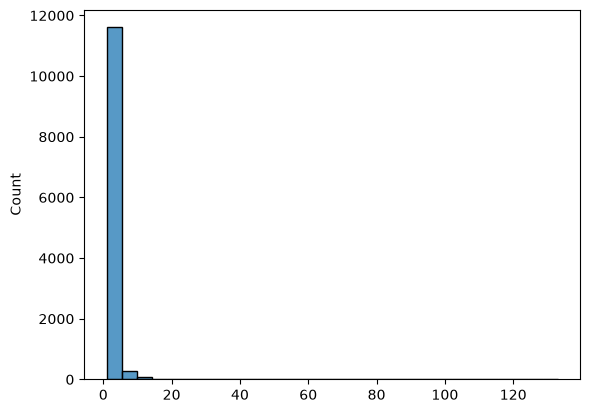

In [12]:
sns.histplot(product_frequency, bins=30)

In [13]:
frequent_products = product_frequency[product_frequency >= 5].index
frequent_products

Index([461686, 119736, 213834,   7943, 312728, 445351,  48030, 248455, 420960,
        17478,
       ...
       183758, 340960, 281211, 177257, 324391, 221290,  44465, 193828,  52039,
       183756],
      dtype='int64', name='itemid', length=654)

In [14]:
basket_filtered = basket[frequent_products]
basket_filtered.shape

(17672, 654)

# Product Frequency Filtering

Before applying the Apriori algorithm, products with very low purchase frequency were removed.

## Why Filter Rare Products?

- Products purchased only a few times provide insufficient evidence to generate reliable association rules.
- Including thousands of rare products dramatically increases computation time while contributing little analytical value.
- Filtering allows the algorithm to focus on products that represent meaningful purchasing patterns.

## Results

- **Original Products:** 12,025
- **Products After Filtering:** 654
- **Feature Reduction:** ~94.6%

## Business Insights

- The product catalog is extremely long-tailed, with the majority of products purchased only a handful of times.
- A relatively small subset of products accounts for most purchasing activity.
- Focusing Market Basket Analysis on frequently purchased products improves both computational efficiency and the quality of generated recommendation rules.

In [15]:
#apriori algo
frequent_itemsets = apriori(basket_filtered,min_support=0.001,use_colnames=True)

frequent_itemsets.sort_values("support",ascending=False).head(20)

#Support =0.001 -means 0.001×17,672≈18 transactions (only itemsets appearing in 18 or more baskets will be kept)

,support,itemsets
0,0.007526,frozenset({461686})
1,0.005432,frozenset({119736})
2,0.005206,frozenset({213834})
3,0.002603,frozenset({7943})
4,0.002603,frozenset({312728})
5,0.002546,frozenset({445351})
6,0.002320,frozenset({48030})
35,0.002207,"frozenset({213834, 445351})"
8,0.002150,frozenset({420960})
7,0.002150,frozenset({248455})


In [16]:
#Support=Transactions containing itemset/Total transactions

In [17]:
frequent_itemsets.shape

(36, 2)

In [18]:
frequent_itemsets.head()

,support,itemsets
0,0.007526,frozenset({461686})
1,0.005432,frozenset({119736})
2,0.005206,frozenset({213834})
3,0.002603,frozenset({7943})
4,0.002603,frozenset({312728})


- The dataset has an average basket size of only 1.27 products, making transactions extremely sparse. Using a high minimum support would eliminate nearly all meaningful product combinations. Therefore, I selected a low support threshold of 0.001, which corresponds to approximately 18 transactions, allowing the algorithm to discover statistically meaningful but infrequent associations. For datasets with larger basket sizes, I would increase the support threshold because products naturally co-occur more frequently.
- Frequent Itemsets -> support, generated
- now support -> confidence -> lift -> rules

In [19]:
#Generate Association Rules
rules = association_rules(frequent_itemsets, metric="confidence",min_threshold=0.30)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({213834}),frozenset({445351}),0.005206,0.002546,0.002207,0.423913,166.475362,1.0,0.002194,1.731429,0.999195,0.397959,0.422442,0.64529
1,frozenset({445351}),frozenset({213834}),0.002546,0.005206,0.002207,0.866667,166.475362,1.0,0.002194,7.460955,0.996531,0.397959,0.865969,0.64529


In [20]:
rules.shape

(2, 14)

In [21]:
rules = rules.sort_values(by="lift", ascending=False)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({213834}),frozenset({445351}),0.005206,0.002546,0.002207,0.423913,166.475362,1.0,0.002194,1.731429,0.999195,0.397959,0.422442,0.64529
1,frozenset({445351}),frozenset({213834}),0.002546,0.005206,0.002207,0.866667,166.475362,1.0,0.002194,7.460955,0.996531,0.397959,0.865969,0.64529


In [22]:
rules["antecedents"] = rules["antecedents"].apply(lambda x: list(x)[0])
rules["consequents"] = rules["consequents"].apply(lambda x: list(x)[0])

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,213834,445351,0.005206,0.002546,0.002207,0.423913,166.475362,1.0,0.002194,1.731429,0.999195,0.397959,0.422442,0.64529
1,445351,213834,0.002546,0.005206,0.002207,0.866667,166.475362,1.0,0.002194,7.460955,0.996531,0.397959,0.865969,0.64529


# Market Basket Analysis

The Apriori algorithm was applied to identify products that are frequently purchased together.

## Key Findings

- After filtering infrequently purchased products, the Apriori algorithm generated **36 frequent itemsets**.
- Only **2 association rules** satisfied the minimum confidence threshold of **30%**.
- The limited number of rules is consistent with earlier analyses, where the average basket size was only **1.27 products**, indicating that most customers purchase a single item per transaction.

## Strongest Association Rule

- Customers purchasing **Product 213834** also purchased **Product 445351** in **42.39%** of cases.
- Conversely, customers purchasing **Product 445351** also purchased **Product 213834** in **86.67%** of cases.
- Both rules achieved an exceptionally high **Lift of 166.48**, indicating that these products are purchased together far more frequently than would occur by chance.

## Business Insights

- The ecommerce platform exhibits **very limited multi-product purchasing behavior**, resulting in relatively few meaningful association rules.
- The strong relationship between **Products 213834 and 445351** suggests a natural product bundle or complementary relationship.
- These products are strong candidates for:
  - Frequently Bought Together recommendations
  - Bundle discounts
  - Cross-selling campaigns
  - Product page recommendations
- Increasing average basket size through recommendation systems and bundling strategies could significantly improve revenue per transaction.

In [23]:
# checking did this item belong to same category
product_dimension=pd.read_csv('product_dimension.csv')

In [24]:
product_ids = [213834, 445351]

product_dimension[product_dimension["itemid"].isin(product_ids)]

,itemid,categoryid,available,parentid
135917,213834,1163,1,561.0
366773,445351,1483,0,561.0


## Product Category Validation

The strongest association rule was further investigated by mapping the products to their categories.

| Product | Category | Parent Category |
|---------:|----------:|----------------:|
|213834|1163|561|
|445351|1483|561|

### Business Insights

- The two products belong to **different categories**, indicating they are distinct products rather than duplicates.
- However, both categories share the **same parent category (561)**, suggesting they belong to the same broader product family.
- This explains the exceptionally high association strength (Lift = **166.48**), as customers frequently purchase complementary products within this parent category.
- These products are strong candidates for:
  - Frequently Bought Together recommendations
  - Product bundle promotions
  - Cross-selling opportunities
  - Related product suggestions on product pages